## Carga e inspección básica

In [1]:
from sklearn.datasets import fetch_california_housing
import pandas as pd

dataset = fetch_california_housing(as_frame=True)
df = dataset.frame

print(df.shape)
print(df.dtypes)
df.head()

(20640, 9)
MedInc         float64
HouseAge       float64
AveRooms       float64
AveBedrms      float64
Population     float64
AveOccup       float64
Latitude       float64
Longitude      float64
MedHouseVal    float64
dtype: object


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [2]:
print("Nulos por columna:")
print(df.isnull().sum())

df.describe()

Nulos por columna:
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


## Distribución del target

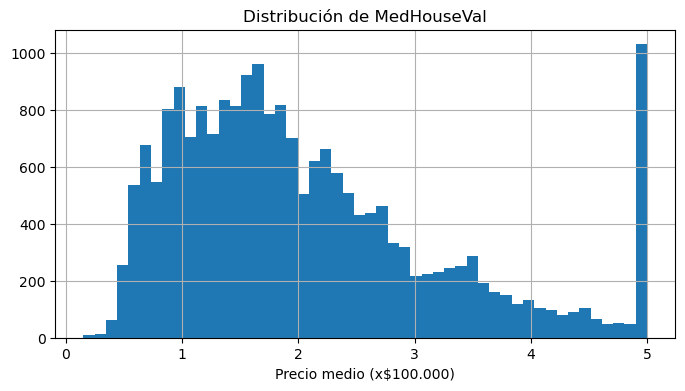

Skewness: 0.98


In [ ]:
import matplotlib.pyplot as plt

df['MedHouseVal'].hist(bins=50, figsize=(8,4))
plt.title('Distribución de MedHouseVal')
plt.xlabel('Precio medio (x$100.000)')
plt.show()

print(f"Skewness: {df['MedHouseVal'].skew():.2f}")

El target tiene un skewness de 0.98. Para Random Forest (el algoritmo que se usará en esta práctica) esto no es un problema ya que los árboles no asumen normalidad en el target. Si hubiéramos usado un modelo lineal, habríamos aplicado log1p para reducir el sesgo.

## Correlaciones con el target

MedHouseVal    1.000000
MedInc         0.688075
AveRooms       0.151948
HouseAge       0.105623
AveOccup      -0.023737
Population    -0.024650
Longitude     -0.045967
AveBedrms     -0.046701
Latitude      -0.144160
Name: MedHouseVal, dtype: float64


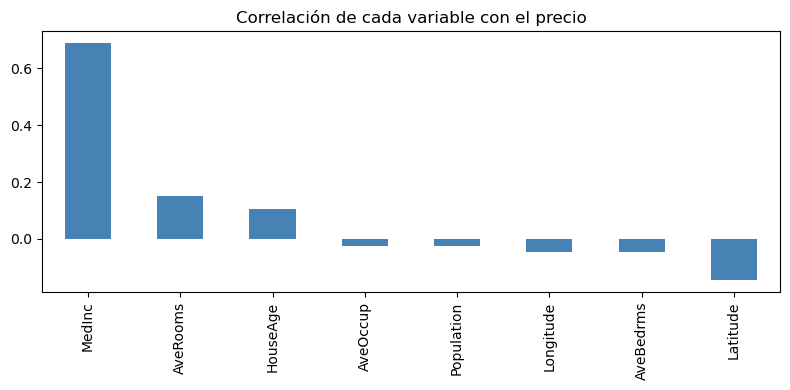

In [12]:
correlaciones = df.corr()['MedHouseVal'].sort_values(ascending=False)
print(correlaciones)

correlaciones.drop('MedHouseVal').plot(kind='bar', figsize=(8,4), color='steelblue')
plt.title('Correlación de cada variable con el precio')
plt.tight_layout()
plt.show()

MedInc con MedHouseVal → ~0.69, la correlación más alta con el target por mucho. Lo que justifica que sea la variable más importante en el modelo.\

## Outliers en AveRooms y AveOccup

In [9]:
print("AveRooms  — percentil 99:", df['AveRooms'].quantile(0.99))
print("AveOccup  — percentil 99:", df['AveOccup'].quantile(0.99))
print("AveOccup  — máximo:      ", df['AveOccup'].max())

# Cuántos registros tienen una ocupación absurda (>10 personas por habitación)
outliers = df[df['AveOccup'] > 10]
print(f"\nRegistros con AveOccup > 10: {len(outliers)} ({len(outliers)/len(df)*100:.1f}%)")

AveRooms  — percentil 99: 10.357033023735815
AveOccup  — percentil 99: 5.394812032520327
AveOccup  — máximo:       1243.3333333333333

Registros con AveOccup > 10: 37 (0.2%)


Valores como el que muestra de 1243, nos dice que son errores del dataset original.\
Son menos del 0.5% de los datos, así que en el script de entrenamiento se pueden simplemente filtrar o ignorar.

## Mapa geográfico de precios

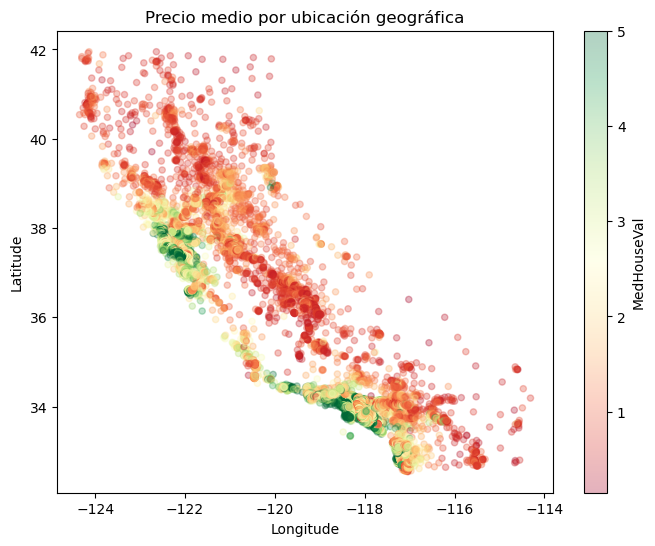

In [10]:
df.plot.scatter(
    x='Longitude', y='Latitude',
    c='MedHouseVal', cmap='RdYlGn',
    alpha=0.3, figsize=(8,6),
    title='Precio medio por ubicación geográfica'
)
plt.show()

Aquí se muestra la costa de California (San Francisco, LA) en verde oscuro (precios altos) y el interior en rojo

## Conclusiones del EDA

- **Sin nulos ni variables categóricas** → no hace falta imputación ni encoding.
- **Target con sesgo moderado** → se podría aplicar log1p, pero no es imprescindible para Random Forest.
- **MedInc domina la correlación** (~0.69) → esperable que sea la variable más importante del modelo.
- **Outliers en AveOccup** → ~100 registros con valores absurdos. Se pueden filtrar con `df = df[df['AveOccup'] < 10]` en load_data.py.
- **Patrón geográfico claro** → Latitude y Longitude aportan información real al modelo.

**Acción tomada en el script de entrenamiento:** filtrar AveOccup > 10 en load_data.py.